# Phase 3: Data Preparation

**CRISP-DM Phase Description:**  
This phase covers all activities needed to construct the final dataset from the initial raw data. Data preparation tasks are likely to be performed multiple times, and not in any prescribed order. Tasks include table, record, and attribute selection as well as transformation and cleaning of data for modelling tools.

**Input:** `fleet_augmented.csv` (20,300 rows × 13 columns, 500 vehicles)  
**Output:** `data/preprocessed/fleet_prepared.csv` — cleaned, feature-enriched, model-ready dataset


**Key issues identified in Phase 2:**
- Missing values: 2–8% across 10 sensor columns
- Physical anomalies: negative `speed_kmh`, negative `distance_m`, `soc_pct` > 100%
- Severe class imbalance: 96.33% Normal vs ~3.67% failure types
- Target: `failure_type` (5 classes: Normal, Critical_Overheating, Thermal_Overload, Mechanical_Stress, Voltage_Sag)

In [ ]:
%pip install scikit-learn

In [10]:
# Standard library imports for this phase
import sys
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
%matplotlib inline

# Paths
DATA_PATH = '../data/raw/fleet_augmented.csv'
OUTPUT_DIR = '../data/preprocessed'
OUTPUT_CSV = os.path.join(OUTPUT_DIR, 'fleet_prepared.csv')
OUTPUT_META = os.path.join(OUTPUT_DIR, 'preparation_metadata.json')

print('Phase 3: Data Preparation')
print(f'Start time: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

Phase 3: Data Preparation
Start time: 2026-06-29 14:59:48


### Task 1: Data Loading & Chronological Sorting

Load the raw dataset and establish per-vehicle time-series continuity by sorting on `[car_id, timestamp]`. This ordering is critical for:
- Correct forward/backward fill imputation (Task 4)
- Rolling window feature engineering without cross-vehicle contamination (Task 5b)

In [11]:
df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
print(f'Date range: {df["timestamp"].min()} -> {df["timestamp"].max()}')
print(f'Unique vehicles: {df["car_id"].nunique()}')
print(f'\nData types:\n{df.dtypes}')

# Sort by car_id and timestamp for time-series continuity
df = df.sort_values(by=['car_id', 'timestamp']).reset_index(drop=True)
print('\n[OK] Sorted by [car_id, timestamp]')

initial_shape = df.shape
df.head()

Dataset shape: 20300 rows x 13 columns
Columns: ['timestamp', 'speed_kmh', 'distance_m', 'soc_pct', 'battery_voltage_v', 'battery_temp_c', 'motor_rpm', 'motor_temp_c', 'power_kw', 'ambient_temp_c', 'load_kg', 'car_id', 'failure_type']
Date range: 2026-01-01 00:00:00 -> 2026-01-03 18:30:00
Unique vehicles: 500

Data types:
timestamp            datetime64[ns]
speed_kmh                   float64
distance_m                  float64
soc_pct                     float64
battery_voltage_v           float64
battery_temp_c              float64
motor_rpm                   float64
motor_temp_c                float64
power_kw                    float64
ambient_temp_c              float64
load_kg                     float64
car_id                       object
failure_type                 object
dtype: object

[OK] Sorted by [car_id, timestamp]


,timestamp,speed_kmh,distance_m,soc_pct,battery_voltage_v,battery_temp_c,motor_rpm,motor_temp_c,power_kw,ambient_temp_c,load_kg,car_id,failure_type
0,2026-01-01 00:00:00,NaN,0.0000,100.0000,400.0000,25.0000,NaN,25.0000,0.0000,25.5000,212.3000,car_1,Normal
1,2026-01-01 00:10:00,62.9300,10464.3800,98.6500,397.1400,24.9600,4472.0000,24.1600,6.1000,24.9600,NaN,car_1,Normal
2,2026-01-01 00:20:00,53.8300,20952.1000,97.3000,398.1900,25.7300,3809.0000,23.1800,4.9500,25.8500,234.1000,car_1,Normal
3,2026-01-01 00:30:00,66.6100,29923.2800,96.2000,396.4500,25.4300,4510.0000,25.8300,5.6900,26.8200,257.2000,car_1,Normal
4,2026-01-01 00:40:00,50.7200,41025.7700,94.9300,396.1100,24.9900,3528.0000,22.6400,NaN,25.1700,307.4000,car_1,Normal


### Task 2: Duplicate Removal

Remove two types of duplicates:
1. **Exact-row duplicates** — identical across all columns
2. **Key duplicates** — same `(car_id, timestamp)` pair, which would corrupt the time-series ordering

In [12]:
n_before = len(df)

# 1. Exact-row duplicates
df = df.drop_duplicates()
n_after_exact = len(df)
print(f'Exact-row duplicates removed: {n_before - n_after_exact}')

# 2. Same (car_id, timestamp) duplicates -- keep first occurrence
df = df.drop_duplicates(subset=['car_id', 'timestamp'], keep='first')
n_after_key = len(df)
print(f'(car_id, timestamp) duplicates removed: {n_after_exact - n_after_key}')
print(f'Rows remaining: {n_after_key} (removed {n_before - n_after_key} total)')

df = df.reset_index(drop=True)

Exact-row duplicates removed: 0
(car_id, timestamp) duplicates removed: 0
Rows remaining: 20300 (removed 0 total)


### Task 3: Physical Constraint Enforcement (Outlier Handling)

Apply **domain-driven clamping** based on Phase 2 findings. Clamping is chosen over deletion to preserve the rare failure-class rows — deleting outliers could disproportionately remove failure events that represent only ~3.67% of the dataset.

| Column | Bound | Rationale |
|---|---|---|
| `speed_kmh` | [0, 200] | Negative speed is physically impossible |
| `distance_m` | [0, +inf] | Negative distance is a sensor error |
| `soc_pct` | [0, 100] | Battery charge cannot exceed 100% |
| `battery_voltage_v` | [250, 500] | EV battery nominal range |
| `battery_temp_c` | [-40, 80] | Reasonable operating range |
| `motor_rpm` | [0, 12000] | Negative RPM is sensor noise |
| `motor_temp_c` | [-20, 120] | Wide allowance for thermal failures |
| `power_kw` | [0, 50] | Physical power bounds |
| `ambient_temp_c` | [-50, 60] | Extreme climate range |
| `load_kg` | [0, 1000] | Vehicle payload limits |

In [13]:
# Physical clamping rules derived from Phase 2 domain analysis
CLAMP_RULES = {
    'speed_kmh':         {'min': 0,    'max': 200},
    'distance_m':        {'min': 0,    'max': None},
    'soc_pct':           {'min': 0,    'max': 100},
    'battery_voltage_v': {'min': 250,  'max': 500},
    'battery_temp_c':    {'min': -40,  'max': 80},
    'motor_rpm':         {'min': 0,    'max': 12000},
    'motor_temp_c':      {'min': -20,  'max': 120},
    'power_kw':          {'min': 0,    'max': 50},
    'ambient_temp_c':    {'min': -50,  'max': 60},
    'load_kg':           {'min': 0,    'max': 1000},
}

violations_report = []

for col, bounds in CLAMP_RULES.items():
    if col not in df.columns:
        continue

    lo = bounds.get('min')
    hi = bounds.get('max')
    violations = 0

    if lo is not None:
        mask_lo = df[col] < lo
        violations += mask_lo.sum()
        df.loc[mask_lo, col] = lo

    if hi is not None:
        mask_hi = df[col] > hi
        violations += mask_hi.sum()
        df.loc[mask_hi, col] = hi

    if violations > 0:
        violations_report.append({
            'column': col,
            'violations_clamped': int(violations),
            'bound': f'[{lo}, {hi}]'
        })

violations_df = pd.DataFrame(violations_report)
print('Physical constraint violations corrected:')
display(violations_df)

# Quick stats after clamping
print('\nPost-clamping statistics (key columns):')
for col in ['speed_kmh', 'soc_pct', 'motor_rpm', 'distance_m']:
    if col in df.columns:
        print(f'  {col:>15s}:  min={df[col].min():.2f}  max={df[col].max():.2f}')

Physical constraint violations corrected:


,column,violations_clamped,bound
0,speed_kmh,26,"[0, 200]"
1,distance_m,1,"[0, None]"
2,soc_pct,29,"[0, 100]"
3,motor_rpm,25,"[0, 12000]"
4,power_kw,25,"[0, 50]"



Post-clamping statistics (key columns):
        speed_kmh:  min=0.00  max=154.19
          soc_pct:  min=0.70  max=100.00
        motor_rpm:  min=0.00  max=10748.04
       distance_m:  min=0.00  max=2569275.27


### Task 4: Missing Value Imputation

**Strategy:**  
1. **Per-vehicle forward-fill then backward-fill** — respects temporal continuity within each vehicle's telemetry stream
2. **Global column median fallback** — handles edge cases where an entire vehicle has NaN for a given column

This approach is preferred over global mean/median-only imputation because sensor readings are temporally correlated within each vehicle's driving session.

In [14]:
# Missing values BEFORE imputation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
missing_before = df[numeric_cols].isnull().sum()
total_missing_before = missing_before.sum()

missing_report = pd.DataFrame({
    'Missing Count': missing_before,
    'Missing %': (missing_before / len(df) * 100).round(2)
})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Total missing values: {total_missing_before}')
display(missing_report)

Total missing values: 9519


,Missing Count,Missing %
motor_temp_c,1634,8.0500
battery_temp_c,1475,7.2700
power_kw,1239,6.1000
soc_pct,1185,5.8400
motor_rpm,1061,5.2300
battery_voltage_v,884,4.3500
load_kg,762,3.7500
speed_kmh,640,3.1500
ambient_temp_c,422,2.0800
distance_m,217,1.0700


In [15]:
df[numeric_cols] = (
    df.groupby('car_id')[numeric_cols]
    .transform(lambda g: g.ffill().bfill())
)

remaining = df[numeric_cols].isnull().sum().sum()
if remaining > 0:
    print(f'Remaining NaN after ffill/bfill: {remaining} -> applying median fallback')
    medians = df[numeric_cols].median()
    df[numeric_cols] = df[numeric_cols].fillna(medians)
    
missing_after = df[numeric_cols].isnull().sum()
total_missing_after = missing_after.sum()

imputation_summary = pd.DataFrame({
    'Before': missing_before,
    'After': missing_after
})
imputation_summary = imputation_summary[imputation_summary['Before'] > 0]
display(imputation_summary)

print(f'\nTotal NaN: {total_missing_before} -> {total_missing_after}')
assert total_missing_after == 0, 'ERROR: NaN values still present!'
print('[OK] Zero missing values confirmed')

Remaining NaN after ffill/bfill: 142 -> applying median fallback


,Before,After
speed_kmh,640,0
distance_m,217,0
soc_pct,1185,0
battery_voltage_v,884,0
battery_temp_c,1475,0
motor_rpm,1061,0
motor_temp_c,1634,0
power_kw,1239,0
ambient_temp_c,422,0
load_kg,762,0



Total NaN: 9519 -> 0
[OK] Zero missing values confirmed


### Task 5: Feature Engineering

Create new predictive features based on the hypotheses identified in Phase 2. These fall into three categories:

- **5a. Interaction & Ratio Features** — physics-informed combinations capturing stress and degradation signals
- **5b. Rolling Window Features** — per-vehicle temporal trends capturing degradation patterns leading up to failures
- **5c. Temporal Features** — operational cycle extraction from timestamps

In [16]:
df['power_to_load_ratio'] = df['power_kw'] / (df['load_kg'] + 1)          # Stress indicator
df['temp_diff_motor_ambient'] = df['motor_temp_c'] - df['ambient_temp_c']  # Thermal excess
df['temp_diff_battery_ambient'] = df['battery_temp_c'] - df['ambient_temp_c']  # Battery thermal stress
df['voltage_per_soc'] = df['battery_voltage_v'] / (df['soc_pct'] + 1)     # Electrical health
df['speed_x_load'] = df['speed_kmh'] * df['load_kg']                      # Kinetic stress proxy

interaction_features = [
    'power_to_load_ratio', 'temp_diff_motor_ambient',
    'temp_diff_battery_ambient', 'voltage_per_soc', 'speed_x_load'
]
print(f'Created {len(interaction_features)} interaction features: {interaction_features}')
df[interaction_features].describe()

Created 5 interaction features: ['power_to_load_ratio', 'temp_diff_motor_ambient', 'temp_diff_battery_ambient', 'voltage_per_soc', 'speed_x_load']


,power_to_load_ratio,temp_diff_motor_ambient,temp_diff_battery_ambient,voltage_per_soc,speed_x_load
count,20300.0000,20300.0000,20300.0000,20300.0000,20300.0000
mean,0.0282,0.0972,0.0372,5.1963,15129.3050
std,0.1288,10.2866,6.2147,2.9925,8785.0892
min,0.0000,-45.8086,-31.8047,3.0011,0.0000
25%,0.0163,-7.1400,-5.2300,4.0969,8183.4560
50%,0.0217,-0.1100,-0.4600,4.2915,13700.7390
75%,0.0280,7.4800,5.6000,5.2701,20938.3013
max,6.4377,52.4946,46.9723,240.1912,62694.9260


In [17]:
ROLLING_COLS = ['motor_temp_c', 'battery_temp_c', 'battery_voltage_v', 'power_kw']
ROLLING_WINDOW = 3

rolling_feature_names = []
for col in ROLLING_COLS:
    mean_col = f'{col}_roll_mean'
    std_col = f'{col}_roll_std'

    grouped = df.groupby('car_id')[col]
    df[mean_col] = grouped.transform(
        lambda x: x.rolling(window=ROLLING_WINDOW, min_periods=1).mean()
    )
    df[std_col] = grouped.transform(
        lambda x: x.rolling(window=ROLLING_WINDOW, min_periods=1).std()
    )
    rolling_feature_names.extend([mean_col, std_col])

std_cols = [c for c in rolling_feature_names if c.endswith('_roll_std')]
df[std_cols] = df[std_cols].fillna(0)

print(f'Created {len(rolling_feature_names)} rolling features (window={ROLLING_WINDOW}):')
for feat in rolling_feature_names:
    print(f'  - {feat}')

Created 8 rolling features (window=3):
  - motor_temp_c_roll_mean
  - motor_temp_c_roll_std
  - battery_temp_c_roll_mean
  - battery_temp_c_roll_std
  - battery_voltage_v_roll_mean
  - battery_voltage_v_roll_std
  - power_kw_roll_mean
  - power_kw_roll_std


In [18]:
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek  # Monday=0, Sunday=6
print('Created: hour_of_day, day_of_week')
print(f'\nHour distribution:\n{df["hour_of_day"].value_counts().sort_index()}')
print(f'\nDay of week distribution:\n{df["day_of_week"].value_counts().sort_index()}')

Created: hour_of_day, day_of_week

Hour distribution:
hour_of_day
0     1212
1     1212
2     1212
3     1212
4     1212
5     1212
6     1212
7     1212
8     1212
9     1212
10    1212
11    1212
12    1212
13    1212
14    1212
15    1212
16     814
17      18
18      16
19      12
20      12
21      12
22      12
23      12
Name: count, dtype: int64

Day of week distribution:
day_of_week
3    20044
4      144
5      112
Name: count, dtype: int64


In [19]:
print(f'Feature count: {initial_shape[1]} original -> {df.shape[1]} total columns')
print(f'New features added: {df.shape[1] - initial_shape[1]}')
print(f'\nAll columns: {df.columns.tolist()}')

Feature count: 13 original -> 28 total columns
New features added: 15

All columns: ['timestamp', 'speed_kmh', 'distance_m', 'soc_pct', 'battery_voltage_v', 'battery_temp_c', 'motor_rpm', 'motor_temp_c', 'power_kw', 'ambient_temp_c', 'load_kg', 'car_id', 'failure_type', 'power_to_load_ratio', 'temp_diff_motor_ambient', 'temp_diff_battery_ambient', 'voltage_per_soc', 'speed_x_load', 'motor_temp_c_roll_mean', 'motor_temp_c_roll_std', 'battery_temp_c_roll_mean', 'battery_temp_c_roll_std', 'battery_voltage_v_roll_mean', 'battery_voltage_v_roll_std', 'power_kw_roll_mean', 'power_kw_roll_std', 'hour_of_day', 'day_of_week']


### Task 6: Target Label Encoding & Class Balance Report

Convert the categorical `failure_type` target into integer labels using `LabelEncoder`.

In [20]:
le = LabelEncoder()
df['failure_type_encoded'] = le.fit_transform(df['failure_type'].astype(str))
label_mapping = dict(zip(le.classes_, le.transform(le.classes_).tolist()))
print('Target label mapping (alphabetical):')
for cls_name, cls_int in label_mapping.items():
    print(f'  {cls_name:>25s}  ->  {cls_int}')

Target label mapping (alphabetical):
       Critical_Overheating  ->  0
          Mechanical_Stress  ->  1
                     Normal  ->  2
           Thermal_Overload  ->  3
                Voltage_Sag  ->  4


,Count,Percentage (%)
failure_type,,
Normal,19554,96.3300
Critical_Overheating,344,1.6900
Thermal_Overload,308,1.5200
Mechanical_Stress,50,0.2500
Voltage_Sag,44,0.2200



Imbalance ratio (majority/minority): 444.4:1
Note: Resampling (SMOTE) deferred to Phase 4 -- applied only to training folds


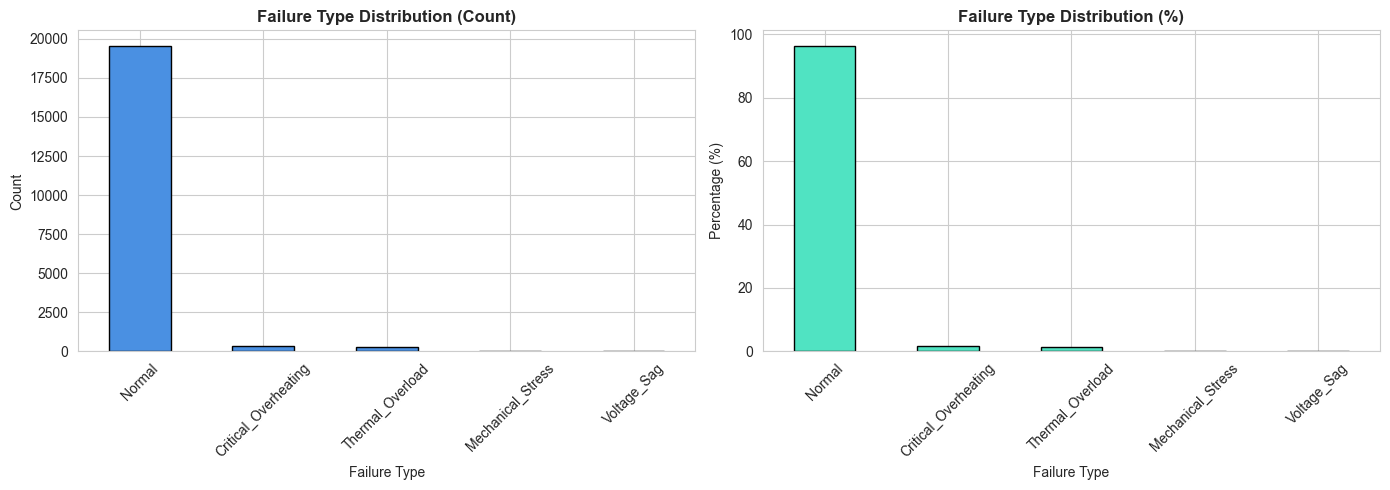

In [30]:
# Class balance report
class_counts = df['failure_type'].value_counts()
class_pct = (class_counts / len(df) * 100).round(2)

balance_report = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct
})
display(balance_report)

majority_count = class_counts.iloc[0]
minority_count = class_counts.iloc[-1]
print(f'\nImbalance ratio (majority/minority): {majority_count / minority_count:.1f}:1')
print('Note: Resampling (SMOTE) deferred to Phase 4 -- applied only to training folds')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.plot(kind='bar', ax=axes[0], color='#4A90E2', edgecolor='black')
axes[0].set_title('Failure Type Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Failure Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

class_pct.plot(kind='bar', ax=axes[1], color='#50E3C2', edgecolor='black')
axes[1].set_title('Failure Type Distribution (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Failure Type')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

# plt.savefig("../figure/failure_type_distribution.png", dpi=300)

plt.show()

#### Class Imbalance Deep-Dive

The class distribution above reveals an **extreme imbalance problem** that will dominate model behaviour if left unaddressed:

| Class | Count | % of Total | Ratio vs Minority |
|---|---|---|---|
| Normal | 19,554 | 96.33% | 444x |
| Critical_Overheating | 344 | 1.69% | 7.8x |
| Thermal_Overload | 308 | 1.52% | 7.0x |
| Mechanical_Stress | 50 | 0.25% | 1.1x |
| Voltage_Sag | 44 | 0.22% | 1.0x (minority) |

**Why we do NOT resample here in Phase 3:**

Applying SMOTE, random oversampling, or undersampling **before** the train/test split would cause **data leakage**:
- SMOTE generates synthetic minority samples by interpolating between existing ones
- If applied to the full dataset, some synthetic samples will be based on test-set points
- This inflates evaluation metrics and gives a false sense of model performance

**Recommended strategies for Phase 4 (Modeling):**

1. **Class Weights** (no leakage risk) -- assign higher misclassification penalties to minority classes via `class_weight='balanced'` in scikit-learn estimators
2. **SMOTE inside CV folds** -- apply SMOTE only to the training fold using `imblearn.pipeline.Pipeline`, never to validation/test data
3. **Stratified Splitting** -- use `StratifiedKFold` / `StratifiedGroupKFold` to preserve class ratios across folds
4. **Evaluation Metrics** -- use Macro-Averaged Recall and ROC-AUC (One-vs-Rest) rather than accuracy, which would be 96.33% by always predicting 'Normal'

The cell below visualises the severity of the imbalance to motivate these Phase 4 decisions.

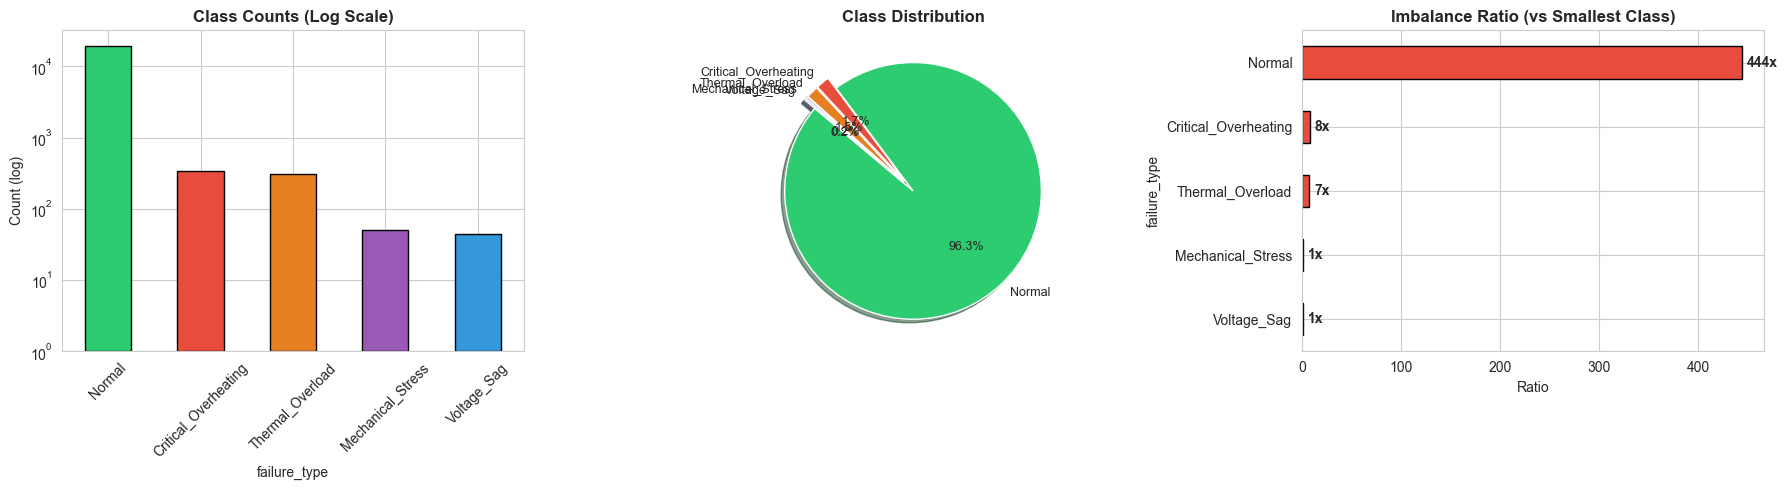


Summary:
  Majority class (Normal):   19554 samples
  Minority class (Voltage_Sag):  44 samples
  Imbalance ratio: 444:1
  -> A naive model predicting "Normal" always would achieve 96.33% accuracy
  -> This is why we use Macro-Recall and ROC-AUC, NOT accuracy


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

class_counts = df['failure_type'].value_counts()
class_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#e67e22', '#9b59b6', '#3498db'],
                  edgecolor='black', log=True)

axes[0].set_title('Class Counts (Log Scale)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count (log)')
axes[0].tick_params(axis='x', rotation=45)

failure_only = class_counts.drop('Normal', errors='ignore')

labels_pie = ['Normal'] + failure_only.index.tolist()
sizes_pie = [class_counts['Normal']] + failure_only.values.tolist()
explode = [0] + [0.1] * len(failure_only)
colors_pie = ['#2ecc71', '#e74c3c', '#e67e22', '#9b59b6', '#3498db']

axes[1].pie(sizes_pie, explode=explode, labels=labels_pie, autopct='%1.1f%%',
            colors=colors_pie, shadow=True, startangle=140, textprops={'fontsize': 9})
axes[1].set_title('Class Distribution', fontsize=12, fontweight='bold')

minority_count = class_counts.min()
imbalance_ratios = (class_counts / minority_count).sort_values(ascending=True)
imbalance_ratios.plot(kind='barh', ax=axes[2], color='#e74c3c', edgecolor='black')

axes[2].set_title('Imbalance Ratio (vs Smallest Class)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Ratio')

for i, (idx, val) in enumerate(imbalance_ratios.items()):
    axes[2].text(val + 5, i, f'{val:.0f}x', va='center', fontweight='bold')

plt.tight_layout()

# plt.savefig("../figure/class_imbalance_analysis.png", dpi=300)

plt.show()

print(f'\nSummary:')
print(f'  Majority class (Normal):  {class_counts["Normal"]:>6} samples')
print(f'  Minority class (Voltage_Sag): {class_counts.min():>3} samples')
print(f'  Imbalance ratio: {class_counts.max() / class_counts.min():.0f}:1')
print(f'  -> A naive model predicting "Normal" always would achieve {class_counts["Normal"]/len(df)*100:.2f}% accuracy')
print(f'  -> This is why we use Macro-Recall and ROC-AUC, NOT accuracy')

---
### Task 7: Final Validation & Export

Run integrity checks on the prepared dataset and export the final cleaned CSV along with a metadata file documenting all transformations applied.

In [23]:
# --- Validation Checks ---
print('Running integrity checks...\n')

numeric_cols_final = df.select_dtypes(include=[np.number]).columns

# Check 1: No NaN
nan_count = df.isnull().sum().sum()
assert nan_count == 0, f'Validation FAILED: {nan_count} NaN values remain.'
print('[OK] Zero NaN values')

# Check 2: No infinities
inf_count = np.isinf(df[numeric_cols_final]).sum().sum()
assert inf_count == 0, f'Validation FAILED: {inf_count} infinite values found.'
print('[OK] Zero infinite values')

# Check 3: Physical bounds enforced
for col, bounds in CLAMP_RULES.items():
    if col not in df.columns:
        continue
    lo = bounds.get('min')
    hi = bounds.get('max')
    if lo is not None:
        assert df[col].min() >= lo, f'FAILED: {col} min = {df[col].min()} < {lo}'
    if hi is not None:
        assert df[col].max() <= hi, f'FAILED: {col} max = {df[col].max()} > {hi}'
print('[OK] Physical bounds enforced')

print('\n[OK] All validation checks PASSED')

Running integrity checks...

[OK] Zero NaN values
[OK] Zero infinite values
[OK] Physical bounds enforced

[OK] All validation checks PASSED


In [24]:
# Final dataset overview
print(f'Final dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nFinal columns ({df.shape[1]}):')
for i, col in enumerate(df.columns):
    print(f'  {i+1:>2}. {col} ({df[col].dtype})')

print('\nFinal descriptive statistics:')
df.describe().transpose()

Final dataset shape: 20300 rows x 29 columns

Final columns (29):
   1. timestamp (datetime64[ns])
   2. speed_kmh (float64)
   3. distance_m (float64)
   4. soc_pct (float64)
   5. battery_voltage_v (float64)
   6. battery_temp_c (float64)
   7. motor_rpm (float64)
   8. motor_temp_c (float64)
   9. power_kw (float64)
  10. ambient_temp_c (float64)
  11. load_kg (float64)
  12. car_id (object)
  13. failure_type (object)
  14. power_to_load_ratio (float64)
  15. temp_diff_motor_ambient (float64)
  16. temp_diff_battery_ambient (float64)
  17. voltage_per_soc (float64)
  18. speed_x_load (float64)
  19. motor_temp_c_roll_mean (float64)
  20. motor_temp_c_roll_std (float64)
  21. battery_temp_c_roll_mean (float64)
  22. battery_temp_c_roll_std (float64)
  23. battery_voltage_v_roll_mean (float64)
  24. battery_voltage_v_roll_std (float64)
  25. power_kw_roll_mean (float64)
  26. power_kw_roll_std (float64)
  27. hour_of_day (int32)
  28. day_of_week (int32)
  29. failure_type_encoded (i

,count,mean,min,25%,50%,75%,max,std
timestamp,20300,2026-01-01 08:44:33.399014912,2026-01-01 00:00:00,2026-01-01 04:10:00,2026-01-01 08:20:00,2026-01-01 12:40:00,2026-01-03 18:30:00,NaN
speed_kmh,20300.0000,59.6181,0.0000,36.0900,59.9100,83.3500,154.1897,26.8577
distance_m,20300.0000,583698.0354,0.0000,196203.3725,435337.4400,806996.2700,2569275.2725,531663.0808
soc_pct,20300.0000,83.8132,0.7009,72.3800,93.8900,100.0000,100.0000,20.7899
battery_voltage_v,20300.0000,398.6718,300.9680,386.1500,397.0800,411.3700,450.0000,18.6214
battery_temp_c,20300.0000,25.0688,1.3963,22.1400,24.9700,28.0900,48.6168,4.4930
motor_rpm,20300.0000,4171.4898,0.0000,2521.0000,4194.5253,5828.2500,10748.0444,1877.1000
motor_temp_c,20300.0000,25.1288,-9.8427,19.2200,24.9800,31.0500,71.7802,9.4396
power_kw,20300.0000,5.4775,0.0000,4.0800,5.5000,6.8900,16.0514,2.0495
ambient_temp_c,20300.0000,25.0316,-19.1296,19.4800,25.1400,30.5700,47.0954,5.9825


In [25]:
# --- Export cleaned CSV ---
os.makedirs(OUTPUT_DIR, exist_ok=True)
df.to_csv(OUTPUT_CSV, index=False)
print(f'[OK] Cleaned dataset exported to: {OUTPUT_CSV}')
print(f'  File size: {os.path.getsize(OUTPUT_CSV) / 1_000_000:.2f} MB')

# --- Export metadata ---
metadata = {
    'phase': 'Phase 3 -- Data Preparation',
    'created_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'input_file': DATA_PATH,
    'output_file': OUTPUT_CSV,
    'original_shape': list(initial_shape),
    'final_shape': list(df.shape),
    'transformations': [
        '1. Chronological sorting by [car_id, timestamp]',
        '2. Duplicate removal (exact rows + car_id/timestamp keys)',
        '3. Physical constraint clamping (domain-driven bounds on 10 sensor columns)',
        '4. Missing value imputation (per-vehicle ffill/bfill + median fallback)',
        '5a. Interaction features: power_to_load_ratio, temp_diff_motor_ambient, '
        'temp_diff_battery_ambient, voltage_per_soc, speed_x_load',
        '5b. Rolling window features (window=3): mean & std for motor_temp_c, '
        'battery_temp_c, battery_voltage_v, power_kw',
        '5c. Temporal features: hour_of_day, day_of_week',
        '6. Target label encoding: failure_type -> failure_type_encoded',
    ],
    'label_mapping': label_mapping,
    'clamping_rules': CLAMP_RULES,
    'notes': [
        'timestamp and car_id retained for traceability -- drop before model training',
        'SMOTE / class balancing deferred to Phase 4 (Modeling) -- applied only on training folds',
        'Rolling features use min_periods=1 to avoid NaN at window edges',
        'Label encoding (LabelEncoder) is NOT target/mean encoding -- no data leakage risk',
    ],
}

with open(OUTPUT_META, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print(f'[OK] Metadata exported to: {OUTPUT_META}')

[OK] Cleaned dataset exported to: ../data/preprocessed\fleet_prepared.csv
  File size: 6.67 MB
[OK] Metadata exported to: ../data/preprocessed\preparation_metadata.json


In [26]:
# --- Phase 3 Summary ---
print('=' * 60)
print('PHASE 3 COMPLETE -- DATA PREPARATION SUMMARY')
print('=' * 60)
print(f'  Input:           {initial_shape[0]} rows x {initial_shape[1]} columns')
print(f'  Output:          {df.shape[0]} rows x {df.shape[1]} columns')
print(f'  Features added:  {df.shape[1] - initial_shape[1]}')
print(f'  Missing values:  0')
print(f'  Target classes:  {len(label_mapping)}')
print(f'  Output file:     {OUTPUT_CSV}')
print(f'  Finish time:     {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 60)

PHASE 3 COMPLETE -- DATA PREPARATION SUMMARY
  Input:           20300 rows x 13 columns
  Output:          20300 rows x 29 columns
  Features added:  16
  Missing values:  0
  Target classes:  5
  Output file:     ../data/preprocessed\fleet_prepared.csv
  Finish time:     2026-06-29 14:59:50
